# Hyperparameter Tuning for Deep Learning Models (ANN & CNN)

This notebook demonstrates hyperparameter tuning for Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) using the Fashion MNIST dataset, TensorFlow/Keras, and scikit-learn's `ParameterSampler` and `ParameterGrid`. It covers manual search, randomized search, and grid search methods, along with comparison and visualization of results.

## 1. Import Required Libraries

In [3]:
# Import TensorFlow and Keras for building neural networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Import NumPy for numerical operations
import numpy as np

# Import Pandas for data manipulation and displaying results in DataFrames
import pandas as pd

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import time for measuring training duration
import time

# Import ParameterSampler and ParameterGrid from scikit-learn for hyperparameter search
from sklearn.model_selection import ParameterSampler, ParameterGrid

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## TASK 1: Hyperparameter Tuning for Artificial Neural Network (ANN)

### 1.1 Load and Preprocess Fashion MNIST Dataset for ANN

In [4]:
# Load the Fashion MNIST dataset
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Split the full training set into training and validation sets
x_valid, x_train = x_train_full[:5000] / 255.0, x_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
x_test = x_test / 255.0 # Normalize test data as well

# Flatten the images for ANN (28x28 images become 784-dimensional vectors)
x_train_flat = x_train.reshape(-1, 28 * 28)
x_valid_flat = x_valid.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

# Print the shapes of the preprocessed data to confirm
print(f"x_train_flat shape: {x_train_flat.shape}")
print(f"x_valid_flat shape: {x_valid_flat.shape}")
print(f"x_test_flat shape: {x_test_flat.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"y_test shape: {y_test.shape}")

# Define class names for Fashion MNIST for better interpretability
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train_flat shape: (55000, 784)
x_valid_flat shape: (5000, 784)
x_test_flat shape: (10000, 784)
y_train shape: (55000,)
y_valid shape: (5000,)
y_test shape: (10000,)


### 1.2 ANN Model Building Function

In [5]:
def build_ann_model(num_neurons=100, optimizer='adam', activation='relu', dropout_rate=0.0):
    """
    Builds and compiles an Artificial Neural Network (ANN) model.

    Args:
        num_neurons (int): Number of neurons in the hidden layer.
        optimizer (str): Optimizer to use (e.g., 'adam', 'sgd').
        activation (str): Activation function for the hidden layer (e.g., 'relu', 'tanh').
        dropout_rate (float): Dropout rate for the dropout layer.

    Returns:
        keras.Model: Compiled Keras Sequential model.
    """
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=[28 * 28]), # Input layer takes flattened images
        keras.layers.Dense(num_neurons, activation=activation), # Hidden layer with adjustable neurons and activation
        keras.layers.Dropout(dropout_rate), # Dropout layer for regularization
        keras.layers.Dense(10, activation='softmax') # Output layer with 10 units for 10 classes (Fashion MNIST)
    ])

    # Compile the model with the specified optimizer, loss function, and metrics
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### 1.3 Hyperparameter Optimization - Manual Search (ANN)

In [6]:
print("Starting Manual Search for ANN...")

# Define combinations of hyperparameters to test manually
manual_params_ann = [
    {'num_neurons': 100, 'optimizer': 'adam', 'activation': 'relu', 'dropout_rate': 0.0, 'batch_size': 32},
    {'num_neurons': 128, 'optimizer': 'sgd', 'activation': 'tanh', 'dropout_rate': 0.1, 'batch_size': 64},
    {'num_neurons': 64, 'optimizer': 'rmsprop', 'activation': 'relu', 'dropout_rate': 0.2, 'batch_size': 32}
]

ann_manual_results = []
best_accuracy_manual_ann = -1
best_params_manual_ann = None

# Initialize EarlyStopping callback to prevent overfitting and speed up training
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for i, params in enumerate(manual_params_ann):
    print(f"\n--- Manual Experiment {i+1}/{len(manual_params_ann)} ---")
    print(f"Parameters: {params}")

    # Build the ANN model with current hyperparameters
    model = build_ann_model(
        num_neurons=params['num_neurons'],
        optimizer=params['optimizer'],
        activation=params['activation'],
        dropout_rate=params['dropout_rate']
    )

    # Record start time for training
    start_time = time.time()

    # Train the model with training and validation data, using EarlyStopping
    history = model.fit(x_train_flat, y_train, epochs=20, # Limited epochs for demonstration
                        validation_data=(x_valid_flat, y_valid),
                        batch_size=params['batch_size'],
                        callbacks=[early_stopping], verbose=0)

    # Record end time and calculate training duration
    training_time = time.time() - start_time

    # Evaluate the model on the validation set
    val_loss, val_accuracy = model.evaluate(x_valid_flat, y_valid, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    # Store the results of the current experiment
    ann_manual_results.append({
        'Method': 'Manual',
        'Num Neurons': params['num_neurons'],
        'Optimizer': params['optimizer'],
        'Activation': params['activation'],
        'Dropout Rate': params['dropout_rate'],
        'Batch Size': params['batch_size'],
        'Validation Accuracy': val_accuracy,
        'Training Time (s)': training_time
    })

    # Update best parameters if current model performs better
    if val_accuracy > best_accuracy_manual_ann:
        best_accuracy_manual_ann = val_accuracy
        best_params_manual_ann = params

# Convert results to a pandas DataFrame for neat display
ann_manual_results_df = pd.DataFrame(ann_manual_results)
print("\n--- Manual Search Results (ANN) ---")
display(ann_manual_results_df)

print(f"\nBest Manual ANN Parameters: {best_params_manual_ann}")
print(f"Best Manual ANN Validation Accuracy: {best_accuracy_manual_ann:.4f}")

Starting Manual Search for ANN...

--- Manual Experiment 1/3 ---
Parameters: {'num_neurons': 100, 'optimizer': 'adam', 'activation': 'relu', 'dropout_rate': 0.0, 'batch_size': 32}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Validation Accuracy: 0.8902
Training Time: 73.16 seconds

--- Manual Experiment 2/3 ---
Parameters: {'num_neurons': 128, 'optimizer': 'sgd', 'activation': 'tanh', 'dropout_rate': 0.1, 'batch_size': 64}
Validation Accuracy: 0.7934
Training Time: 15.50 seconds

--- Manual Experiment 3/3 ---
Parameters: {'num_neurons': 64, 'optimizer': 'rmsprop', 'activation': 'relu', 'dropout_rate': 0.2, 'batch_size': 32}
Validation Accuracy: 0.8516
Training Time: 26.91 seconds

--- Manual Search Results (ANN) ---


,Method,Num Neurons,Optimizer,Activation,Dropout Rate,Batch Size,Validation Accuracy,Training Time (s)
0,Manual,100,adam,relu,0.0,32,0.8902,73.160383
1,Manual,128,sgd,tanh,0.1,64,0.7934,15.497807
2,Manual,64,rmsprop,relu,0.2,32,0.8516,26.905638



Best Manual ANN Parameters: {'num_neurons': 100, 'optimizer': 'adam', 'activation': 'relu', 'dropout_rate': 0.0, 'batch_size': 32}
Best Manual ANN Validation Accuracy: 0.8902


### 1.4 Hyperparameter Optimization - Randomized Search (ANN)

In [7]:
print("Starting Randomized Search for ANN...")

# Define the hyperparameter distributions for Randomized Search
param_distributions_ann = {
    'num_neurons': [64, 128, 256],
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.1, 0.2, 0.3],
    'batch_size': [32, 64, 128]
}

# Create a ParameterSampler to sample 10 random combinations
# `n_iter` specifies the number of samples to draw
random_search_sampler_ann = ParameterSampler(param_distributions_ann, n_iter=10, random_state=42)

ann_random_results = []
best_accuracy_random_ann = -1
best_params_random_ann = None

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for i, params in enumerate(random_search_sampler_ann):
    print(f"\n--- Randomized Experiment {i+1}/10 ---")
    print(f"Parameters: {params}")

    # Build the ANN model with current hyperparameters
    model = build_ann_model(
        num_neurons=params['num_neurons'],
        optimizer=params['optimizer'],
        activation=params['activation'],
        dropout_rate=params['dropout_rate']
    )

    start_time = time.time()

    # Train the model
    history = model.fit(x_train_flat, y_train, epochs=20, # Limited epochs
                        validation_data=(x_valid_flat, y_valid),
                        batch_size=params['batch_size'],
                        callbacks=[early_stopping], verbose=0)

    training_time = time.time() - start_time

    # Evaluate the model
    val_loss, val_accuracy = model.evaluate(x_valid_flat, y_valid, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    # Store results
    ann_random_results.append({
        'Method': 'Randomized',
        'Num Neurons': params['num_neurons'],
        'Optimizer': params['optimizer'],
        'Activation': params['activation'],
        'Dropout Rate': params['dropout_rate'],
        'Batch Size': params['batch_size'],
        'Validation Accuracy': val_accuracy,
        'Training Time (s)': training_time
    })

    # Update best parameters
    if val_accuracy > best_accuracy_random_ann:
        best_accuracy_random_ann = val_accuracy
        best_params_random_ann = params

# Convert results to a pandas DataFrame
ann_random_results_df = pd.DataFrame(ann_random_results)
print("\n--- Randomized Search Results (ANN) ---")
display(ann_random_results_df)

print(f"\nBest Randomized ANN Parameters: {best_params_random_ann}")
print(f"Best Randomized ANN Validation Accuracy: {best_accuracy_random_ann:.4f}")

Starting Randomized Search for ANN...

--- Randomized Experiment 1/10 ---
Parameters: {'optimizer': 'adam', 'num_neurons': 256, 'dropout_rate': 0.2, 'batch_size': 32, 'activation': 'tanh'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Validation Accuracy: 0.8920
Training Time: 94.64 seconds

--- Randomized Experiment 2/10 ---
Parameters: {'optimizer': 'adam', 'num_neurons': 64, 'dropout_rate': 0.0, 'batch_size': 32, 'activation': 'tanh'}
Validation Accuracy: 0.8626
Training Time: 29.77 seconds

--- Randomized Experiment 3/10 ---
Parameters: {'optimizer': 'rmsprop', 'num_neurons': 64, 'dropout_rate': 0.3, 'batch_size': 32, 'activation': 'tanh'}
Validation Accuracy: 0.8412
Training Time: 26.10 seconds

--- Randomized Experiment 4/10 ---
Parameters: {'optimizer': 'adam', 'num_neurons': 64, 'dropout_rate': 0.1, 'batch_size': 32, 'activation': 'relu'}
Validation Accuracy: 0.8614
Training Time: 26.82 seconds

--- Randomized Experiment 5/10 ---
Parameters: {'optimizer': 'adam', 'num_neurons': 64, 'dropout_rate': 0.0, 'batch_size': 128, 'activation': 'tanh'}
Validation Accuracy: 0.8546
Training Time: 9.98 seconds

--- Randomized Experiment 6/10 ---
Parameters: {'optimizer': 'adam', 'num_neurons': 64, 'dropout_rate': 0.2, 'b

,Method,Num Neurons,Optimizer,Activation,Dropout Rate,Batch Size,Validation Accuracy,Training Time (s)
0,Randomized,256,adam,tanh,0.2,32,0.8920,94.637366
1,Randomized,64,adam,tanh,0.0,32,0.8626,29.770384
2,Randomized,64,rmsprop,tanh,0.3,32,0.8412,26.096885
3,Randomized,64,adam,relu,0.1,32,0.8614,26.820492
4,Randomized,64,adam,tanh,0.0,128,0.8546,9.976779
5,Randomized,64,adam,tanh,0.2,32,0.8600,28.776189
6,Randomized,128,adam,sigmoid,0.0,32,0.8536,26.509544
7,Randomized,256,sgd,tanh,0.1,128,0.7754,10.050937
8,Randomized,128,rmsprop,sigmoid,0.1,64,0.8314,15.465135
9,Randomized,64,adam,tanh,0.0,64,0.8556,16.797622



Best Randomized ANN Parameters: {'optimizer': 'adam', 'num_neurons': 256, 'dropout_rate': 0.2, 'batch_size': 32, 'activation': 'tanh'}
Best Randomized ANN Validation Accuracy: 0.8920


### 1.5 Hyperparameter Optimization - Grid Search (ANN)

In [8]:
print("Starting Grid Search for ANN...")

# Define the hyperparameter grid for Grid Search
# Note: Grid Search can be computationally expensive, so use a smaller grid for demonstration
param_grid_ann = {
    'num_neurons': [64, 128],
    'optimizer': ['adam', 'sgd'],
    'activation': ['relu', 'tanh'],
    'dropout_rate': [0.0, 0.2],
    'batch_size': [32, 64]
}

# Create a ParameterGrid to get all possible combinations
grid_search_ann = ParameterGrid(param_grid_ann)

ann_grid_results = []
best_accuracy_grid_ann = -1
best_params_grid_ann = None

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Calculate total number of combinations
total_combinations = len(list(ParameterGrid(param_grid_ann)))

for i, params in enumerate(grid_search_ann):
    print(f"\n--- Grid Experiment {i+1}/{total_combinations} ---")
    print(f"Parameters: {params}")

    # Build the ANN model
    model = build_ann_model(
        num_neurons=params['num_neurons'],
        optimizer=params['optimizer'],
        activation=params['activation'],
        dropout_rate=params['dropout_rate']
    )

    start_time = time.time()

    # Train the model
    history = model.fit(x_train_flat, y_train, epochs=20, # Limited epochs
                        validation_data=(x_valid_flat, y_valid),
                        batch_size=params['batch_size'],
                        callbacks=[early_stopping], verbose=0)

    training_time = time.time() - start_time

    # Evaluate the model
    val_loss, val_accuracy = model.evaluate(x_valid_flat, y_valid, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    # Store results
    ann_grid_results.append({
        'Method': 'Grid',
        'Num Neurons': params['num_neurons'],
        'Optimizer': params['optimizer'],
        'Activation': params['activation'],
        'Dropout Rate': params['dropout_rate'],
        'Batch Size': params['batch_size'],
        'Validation Accuracy': val_accuracy,
        'Training Time (s)': training_time
    })

    # Update best parameters
    if val_accuracy > best_accuracy_grid_ann:
        best_accuracy_grid_ann = val_accuracy
        best_params_grid_ann = params

# Convert results to a pandas DataFrame
ann_grid_results_df = pd.DataFrame(ann_grid_results)
print("\n--- Grid Search Results (ANN) ---")
display(ann_grid_results_df)

print(f"\nBest Grid ANN Parameters: {best_params_grid_ann}")
print(f"Best Grid ANN Validation Accuracy: {best_accuracy_grid_ann:.4f}")

Starting Grid Search for ANN...

--- Grid Experiment 1/32 ---
Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'num_neurons': 64, 'optimizer': 'adam'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Validation Accuracy: 0.8890
Training Time: 74.26 seconds

--- Grid Experiment 2/32 ---
Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'num_neurons': 64, 'optimizer': 'sgd'}
Validation Accuracy: 0.8172
Training Time: 24.51 seconds

--- Grid Experiment 3/32 ---
Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'num_neurons': 128, 'optimizer': 'adam'}
Validation Accuracy: 0.8912
Training Time: 60.78 seconds

--- Grid Experiment 4/32 ---
Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'num_neurons': 128, 'optimizer': 'sgd'}
Validation Accuracy: 0.8216
Training Time: 23.97 seconds

--- Grid Experiment 5/32 ---
Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.2, 'num_neurons': 64, 'optimizer': 'adam'}
Validation Accuracy: 0.8612
Training Time: 26.27 seconds

--- Grid Experiment 6/32 ---
Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.2, 'num_neurons': 64, 'optimizer': 'sg

,Method,Num Neurons,Optimizer,Activation,Dropout Rate,Batch Size,Validation Accuracy,Training Time (s)
0,Grid,64,adam,relu,0.0,32,0.8890,74.256403
1,Grid,64,sgd,relu,0.0,32,0.8172,24.506494
2,Grid,128,adam,relu,0.0,32,0.8912,60.780979
3,Grid,128,sgd,relu,0.0,32,0.8216,23.970041
4,Grid,64,adam,relu,0.2,32,0.8612,26.272192
5,Grid,64,sgd,relu,0.2,32,0.8034,24.758169
6,Grid,128,adam,relu,0.2,32,0.8908,75.661520
7,Grid,128,sgd,relu,0.2,32,0.8186,26.266311
8,Grid,64,adam,relu,0.0,64,0.8564,13.977943
9,Grid,64,sgd,relu,0.0,64,0.7876,13.444886



Best Grid ANN Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.0, 'num_neurons': 128, 'optimizer': 'adam'}
Best Grid ANN Validation Accuracy: 0.8912


### 1.6 Comparison and Visualization (ANN)

--- ANN Hyperparameter Search Comparison ---


,Method,Best Parameters,Validation Accuracy,Training Time (s)
0,Manual Search,"{'num_neurons': 100, 'optimizer': 'adam', 'act...",0.8902,38.521276
1,Randomized Search,"{'optimizer': 'adam', 'num_neurons': 256, 'dro...",0.8920,28.490133
2,Grid Search,"{'activation': 'relu', 'batch_size': 32, 'drop...",0.8912,24.193236



Final Best ANN Model Configuration: {'optimizer': 'adam', 'num_neurons': 256, 'dropout_rate': 0.2, 'batch_size': 32, 'activation': 'tanh'}
With Validation Accuracy: 0.8920


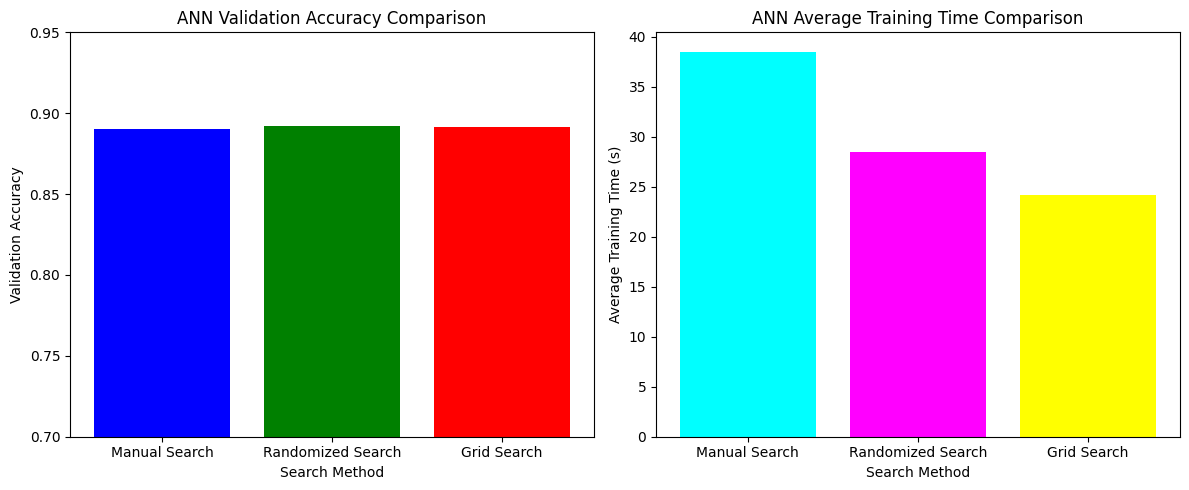

In [9]:
# Combine best results from all ANN search methods into a comparison DataFrame
ann_comparison_data = {
    'Method': ['Manual Search', 'Randomized Search', 'Grid Search'],
    'Best Parameters': [str(best_params_manual_ann), str(best_params_random_ann), str(best_params_grid_ann)],
    'Validation Accuracy': [best_accuracy_manual_ann, best_accuracy_random_ann, best_accuracy_grid_ann],
    'Training Time (s)': [ann_manual_results_df['Training Time (s)'].sum() / len(ann_manual_results_df), # Average time for manual
                            ann_random_results_df['Training Time (s)'].sum() / len(ann_random_results_df), # Average time for randomized
                            ann_grid_results_df['Training Time (s)'].sum() / len(ann_grid_results_df)] # Average time for grid
}

ann_comparison_df = pd.DataFrame(ann_comparison_data)
print("--- ANN Hyperparameter Search Comparison ---")
display(ann_comparison_df)

# Determine the overall best ANN configuration
overall_best_ann_accuracy = max(best_accuracy_manual_ann, best_accuracy_random_ann, best_accuracy_grid_ann)
if overall_best_ann_accuracy == best_accuracy_manual_ann:
    overall_best_ann_params = best_params_manual_ann
elif overall_best_ann_accuracy == best_accuracy_random_ann:
    overall_best_ann_params = best_params_random_ann
else:
    overall_best_ann_params = best_params_grid_ann

print(f"\nFinal Best ANN Model Configuration: {overall_best_ann_params}")
print(f"With Validation Accuracy: {overall_best_ann_accuracy:.4f}")

# Plotting Validation Accuracy comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.bar(ann_comparison_df['Method'], ann_comparison_df['Validation Accuracy'], color=['blue', 'green', 'red'])
plt.title('ANN Validation Accuracy Comparison')
plt.xlabel('Search Method')
plt.ylabel('Validation Accuracy')
plt.ylim(0.7, 0.95) # Set y-axis limits for better visualization

# Plotting Training Time comparison
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.bar(ann_comparison_df['Method'], ann_comparison_df['Training Time (s)'], color=['cyan', 'magenta', 'yellow'])
plt.title('ANN Average Training Time Comparison')
plt.xlabel('Search Method')
plt.ylabel('Average Training Time (s)')

plt.tight_layout()
plt.show()

## TASK 2: Hyperparameter Tuning for Convolutional Neural Network (CNN)

### 2.1 Data Preprocessing for CNN

In [10]:
# Reshape the preprocessed data to add a channel dimension for CNNs
# Images are 28x28 pixels, so reshape to (28, 28, 1) for grayscale
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_valid_cnn = x_valid.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Print shapes to confirm the new dimensions
print(f"x_train_cnn shape: {x_train_cnn.shape}")
print(f"x_valid_cnn shape: {x_valid_cnn.shape}")
print(f"x_test_cnn shape: {x_test_cnn.shape}")

x_train_cnn shape: (55000, 28, 28, 1)
x_valid_cnn shape: (5000, 28, 28, 1)
x_test_cnn shape: (10000, 28, 28, 1)


### 2.2 CNN Model Building Function

In [11]:
def build_cnn_model(num_filters=32, kernel_size=(3, 3), optimizer='adam', dense_units=128, dropout_rate=0.0):
    """
    Builds and compiles a Convolutional Neural Network (CNN) model.

    Args:
        num_filters (int): Number of filters for the first convolutional layer.
        kernel_size (tuple): Size of the convolutional kernel (e.g., (3, 3)).
        optimizer (str): Optimizer to use.
        dense_units (int): Number of units in the dense (fully connected) layer.
        dropout_rate (float): Dropout rate after the dense layer.

    Returns:
        keras.Model: Compiled Keras Sequential model.
    """
    model = keras.Sequential([
        keras.layers.Conv2D(num_filters, kernel_size, activation='relu', input_shape=(28, 28, 1)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(10, activation='softmax') # Output layer for 10 classes
    ])

    # Compile the model
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### 2.3 Hyperparameter Optimization - Manual Search (CNN)

In [12]:
print("Starting Manual Search for CNN...")

# Define manual hyperparameter combinations for CNN
manual_params_cnn = [
    {'num_filters': 32, 'kernel_size': (3, 3), 'optimizer': 'adam', 'dense_units': 128, 'dropout_rate': 0.0, 'batch_size': 32},
    {'num_filters': 64, 'kernel_size': (5, 5), 'optimizer': 'sgd', 'dense_units': 64, 'dropout_rate': 0.2, 'batch_size': 64},
    {'num_filters': 32, 'kernel_size': (3, 3), 'optimizer': 'rmsprop', 'dense_units': 128, 'dropout_rate': 0.1, 'batch_size': 32}
]

cnn_manual_results = []
best_accuracy_manual_cnn = -1
best_params_manual_cnn = None

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for i, params in enumerate(manual_params_cnn):
    print(f"\n--- Manual Experiment {i+1}/{len(manual_params_cnn)} ---")
    print(f"Parameters: {params}")

    model = build_cnn_model(
        num_filters=params['num_filters'],
        kernel_size=params['kernel_size'],
        optimizer=params['optimizer'],
        dense_units=params['dense_units'],
        dropout_rate=params['dropout_rate']
    )

    start_time = time.time()
    history = model.fit(x_train_cnn, y_train, epochs=20, # Limited epochs
                        validation_data=(x_valid_cnn, y_valid),
                        batch_size=params['batch_size'],
                        callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    val_loss, val_accuracy = model.evaluate(x_valid_cnn, y_valid, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    cnn_manual_results.append({
        'Method': 'Manual',
        'Num Filters': params['num_filters'],
        'Kernel Size': params['kernel_size'],
        'Optimizer': params['optimizer'],
        'Dense Units': params['dense_units'],
        'Dropout Rate': params['dropout_rate'],
        'Batch Size': params['batch_size'],
        'Validation Accuracy': val_accuracy,
        'Training Time (s)': training_time
    })

    if val_accuracy > best_accuracy_manual_cnn:
        best_accuracy_manual_cnn = val_accuracy
        best_params_manual_cnn = params

cnn_manual_results_df = pd.DataFrame(cnn_manual_results)
print("\n--- Manual Search Results (CNN) ---")
display(cnn_manual_results_df)

print(f"\nBest Manual CNN Parameters: {best_params_manual_cnn}")
print(f"Best Manual CNN Validation Accuracy: {best_accuracy_manual_cnn:.4f}")

Starting Manual Search for CNN...

--- Manual Experiment 1/3 ---
Parameters: {'num_filters': 32, 'kernel_size': (3, 3), 'optimizer': 'adam', 'dense_units': 128, 'dropout_rate': 0.0, 'batch_size': 32}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9086
Training Time: 47.81 seconds

--- Manual Experiment 2/3 ---
Parameters: {'num_filters': 64, 'kernel_size': (5, 5), 'optimizer': 'sgd', 'dense_units': 64, 'dropout_rate': 0.2, 'batch_size': 64}
Validation Accuracy: 0.7654
Training Time: 20.48 seconds

--- Manual Experiment 3/3 ---
Parameters: {'num_filters': 32, 'kernel_size': (3, 3), 'optimizer': 'rmsprop', 'dense_units': 128, 'dropout_rate': 0.1, 'batch_size': 32}
Validation Accuracy: 0.8898
Training Time: 30.84 seconds

--- Manual Search Results (CNN) ---


,Method,Num Filters,Kernel Size,Optimizer,Dense Units,Dropout Rate,Batch Size,Validation Accuracy,Training Time (s)
0,Manual,32,"(3, 3)",adam,128,0.0,32,0.9086,47.810493
1,Manual,64,"(5, 5)",sgd,64,0.2,64,0.7654,20.480884
2,Manual,32,"(3, 3)",rmsprop,128,0.1,32,0.8898,30.836806



Best Manual CNN Parameters: {'num_filters': 32, 'kernel_size': (3, 3), 'optimizer': 'adam', 'dense_units': 128, 'dropout_rate': 0.0, 'batch_size': 32}
Best Manual CNN Validation Accuracy: 0.9086


### 2.4 Hyperparameter Optimization - Randomized Search (CNN)

In [13]:
print("Starting Randomized Search for CNN...")

# Define hyperparameter distributions for Randomized Search (CNN)
param_distributions_cnn = {
    'num_filters': [16, 32, 64],
    'kernel_size': [(3, 3), (5, 5)],
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'dense_units': [64, 128, 256],
    'dropout_rate': [0.0, 0.2, 0.3],
    'batch_size': [32, 64, 128]
}

random_search_sampler_cnn = ParameterSampler(param_distributions_cnn, n_iter=10, random_state=42)

cnn_random_results = []
best_accuracy_random_cnn = -1
best_params_random_cnn = None

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for i, params in enumerate(random_search_sampler_cnn):
    print(f"\n--- Randomized Experiment {i+1}/10 ---")
    print(f"Parameters: {params}")

    model = build_cnn_model(
        num_filters=params['num_filters'],
        kernel_size=params['kernel_size'],
        optimizer=params['optimizer'],
        dense_units=params['dense_units'],
        dropout_rate=params['dropout_rate']
    )

    start_time = time.time()
    history = model.fit(x_train_cnn, y_train, epochs=20, # Limited epochs
                        validation_data=(x_valid_cnn, y_valid),
                        batch_size=params['batch_size'],
                        callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    val_loss, val_accuracy = model.evaluate(x_valid_cnn, y_valid, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    cnn_random_results.append({
        'Method': 'Randomized',
        'Num Filters': params['num_filters'],
        'Kernel Size': params['kernel_size'],
        'Optimizer': params['optimizer'],
        'Dense Units': params['dense_units'],
        'Dropout Rate': params['dropout_rate'],
        'Batch Size': params['batch_size'],
        'Validation Accuracy': val_accuracy,
        'Training Time (s)': training_time
    })

    if val_accuracy > best_accuracy_random_cnn:
        best_accuracy_random_cnn = val_accuracy
        best_params_random_cnn = params

cnn_random_results_df = pd.DataFrame(cnn_random_results)
print("\n--- Randomized Search Results (CNN) ---")
display(cnn_random_results_df)

print(f"\nBest Randomized CNN Parameters: {best_params_random_cnn}")
print(f"Best Randomized CNN Validation Accuracy: {best_accuracy_random_cnn:.4f}")

Starting Randomized Search for CNN...

--- Randomized Experiment 1/10 ---
Parameters: {'optimizer': 'adam', 'num_filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.3, 'dense_units': 128, 'batch_size': 128}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9170
Training Time: 30.61 seconds

--- Randomized Experiment 2/10 ---
Parameters: {'optimizer': 'sgd', 'num_filters': 16, 'kernel_size': (5, 5), 'dropout_rate': 0.3, 'dense_units': 128, 'batch_size': 64}
Validation Accuracy: 0.7694
Training Time: 17.63 seconds

--- Randomized Experiment 3/10 ---
Parameters: {'optimizer': 'rmsprop', 'num_filters': 64, 'kernel_size': (5, 5), 'dropout_rate': 0.3, 'dense_units': 128, 'batch_size': 128}
Validation Accuracy: 0.8802
Training Time: 14.82 seconds

--- Randomized Experiment 4/10 ---
Parameters: {'optimizer': 'sgd', 'num_filters': 64, 'kernel_size': (5, 5), 'dropout_rate': 0.0, 'dense_units': 256, 'batch_size': 128}
Validation Accuracy: 0.7718
Training Time: 13.76 seconds

--- Randomized Experiment 5/10 ---
Parameters: {'optimizer': 'sgd', 'num_filters': 32, 'kernel_size': (3, 3), 'dropout_rate': 0.3, 'dense_units': 64, 'batch_size': 128}
Validation Accuracy: 0.7610
Training Time: 13.22 seconds

--- Randomized Experiment 6/

,Method,Num Filters,Kernel Size,Optimizer,Dense Units,Dropout Rate,Batch Size,Validation Accuracy,Training Time (s)
0,Randomized,64,"(3, 3)",adam,128,0.3,128,0.9170,30.609462
1,Randomized,16,"(5, 5)",sgd,128,0.3,64,0.7694,17.630476
2,Randomized,64,"(5, 5)",rmsprop,128,0.3,128,0.8802,14.817246
3,Randomized,64,"(5, 5)",sgd,256,0.0,128,0.7718,13.762253
4,Randomized,32,"(3, 3)",sgd,64,0.3,128,0.7610,13.219676
5,Randomized,64,"(5, 5)",adam,256,0.2,128,0.8858,15.772193
6,Randomized,32,"(5, 5)",sgd,64,0.2,64,0.7756,17.856380
7,Randomized,16,"(5, 5)",adam,128,0.0,64,0.8782,17.825631
8,Randomized,32,"(5, 5)",rmsprop,128,0.3,32,0.8936,31.341025
9,Randomized,32,"(5, 5)",sgd,128,0.0,64,0.7396,17.264344



Best Randomized CNN Parameters: {'optimizer': 'adam', 'num_filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.3, 'dense_units': 128, 'batch_size': 128}
Best Randomized CNN Validation Accuracy: 0.9170


### 2.5 Hyperparameter Optimization - Grid Search (CNN)

In [14]:
print("Starting Grid Search for CNN...")

# Define hyperparameter grid for Grid Search (CNN)
# Keeping the grid smaller due to computational cost
param_grid_cnn = {
    'num_filters': [16, 32],
    'kernel_size': [(3, 3)], # Fewer kernel sizes for faster computation
    'optimizer': ['adam', 'sgd'],
    'dense_units': [64, 128],
    'dropout_rate': [0.0, 0.2],
    'batch_size': [32, 64]
}

grid_search_cnn = ParameterGrid(param_grid_cnn)

cnn_grid_results = []
best_accuracy_grid_cnn = -1
best_params_grid_cnn = None

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

total_combinations_cnn = len(list(ParameterGrid(param_grid_cnn)))

for i, params in enumerate(grid_search_cnn):
    print(f"\n--- Grid Experiment {i+1}/{total_combinations_cnn} ---")
    print(f"Parameters: {params}")

    model = build_cnn_model(
        num_filters=params['num_filters'],
        kernel_size=params['kernel_size'],
        optimizer=params['optimizer'],
        dense_units=params['dense_units'],
        dropout_rate=params['dropout_rate']
    )

    start_time = time.time()
    history = model.fit(x_train_cnn, y_train, epochs=20, # Limited epochs
                        validation_data=(x_valid_cnn, y_valid),
                        batch_size=params['batch_size'],
                        callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    val_loss, val_accuracy = model.evaluate(x_valid_cnn, y_valid, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    cnn_grid_results.append({
        'Method': 'Grid',
        'Num Filters': params['num_filters'],
        'Kernel Size': params['kernel_size'],
        'Optimizer': params['optimizer'],
        'Dense Units': params['dense_units'],
        'Dropout Rate': params['dropout_rate'],
        'Batch Size': params['batch_size'],
        'Validation Accuracy': val_accuracy,
        'Training Time (s)': training_time
    })

    if val_accuracy > best_accuracy_grid_cnn:
        best_accuracy_grid_cnn = val_accuracy
        best_params_grid_cnn = params

cnn_grid_results_df = pd.DataFrame(cnn_grid_results)
print("\n--- Grid Search Results (CNN) ---")
display(cnn_grid_results_df)

print(f"\nBest Grid CNN Parameters: {best_params_grid_cnn}")
print(f"Best Grid CNN Validation Accuracy: {best_accuracy_grid_cnn:.4f}")

Starting Grid Search for CNN...

--- Grid Experiment 1/32 ---
Parameters: {'batch_size': 32, 'dense_units': 64, 'dropout_rate': 0.0, 'kernel_size': (3, 3), 'num_filters': 16, 'optimizer': 'adam'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9108
Training Time: 56.27 seconds

--- Grid Experiment 2/32 ---
Parameters: {'batch_size': 32, 'dense_units': 64, 'dropout_rate': 0.0, 'kernel_size': (3, 3), 'num_filters': 16, 'optimizer': 'sgd'}
Validation Accuracy: 0.8120
Training Time: 28.38 seconds

--- Grid Experiment 3/32 ---
Parameters: {'batch_size': 32, 'dense_units': 64, 'dropout_rate': 0.0, 'kernel_size': (3, 3), 'num_filters': 32, 'optimizer': 'adam'}
Validation Accuracy: 0.9134
Training Time: 51.67 seconds

--- Grid Experiment 4/32 ---
Parameters: {'batch_size': 32, 'dense_units': 64, 'dropout_rate': 0.0, 'kernel_size': (3, 3), 'num_filters': 32, 'optimizer': 'sgd'}
Validation Accuracy: 0.8062
Training Time: 28.14 seconds

--- Grid Experiment 5/32 ---
Parameters: {'batch_size': 32, 'dense_units': 64, 'dropout_rate': 0.2, 'kernel_size': (3, 3), 'num_filters': 16, 'optimizer': 'adam'}
Validation Accuracy: 0.8816
Training Time: 30.35 seconds

--- Grid Experiment 6/32 ---
Parameters: {'batch_size': 32, 

,Method,Num Filters,Kernel Size,Optimizer,Dense Units,Dropout Rate,Batch Size,Validation Accuracy,Training Time (s)
0,Grid,16,"(3, 3)",adam,64,0.0,32,0.9108,56.269841
1,Grid,16,"(3, 3)",sgd,64,0.0,32,0.8120,28.383226
2,Grid,32,"(3, 3)",adam,64,0.0,32,0.9134,51.674664
3,Grid,32,"(3, 3)",sgd,64,0.0,32,0.8062,28.141363
4,Grid,16,"(3, 3)",adam,64,0.2,32,0.8816,30.345496
5,Grid,16,"(3, 3)",sgd,64,0.2,32,0.8068,29.506523
6,Grid,32,"(3, 3)",adam,64,0.2,32,0.9094,61.726988
7,Grid,32,"(3, 3)",sgd,64,0.2,32,0.8018,28.914806
8,Grid,16,"(3, 3)",adam,128,0.0,32,0.8856,29.319063
9,Grid,16,"(3, 3)",sgd,128,0.0,32,0.8152,27.800235



Best Grid CNN Parameters: {'batch_size': 32, 'dense_units': 128, 'dropout_rate': 0.2, 'kernel_size': (3, 3), 'num_filters': 32, 'optimizer': 'adam'}
Best Grid CNN Validation Accuracy: 0.9228


### 2.6 Comparison and Visualization (CNN)

--- CNN Hyperparameter Search Comparison ---


,Method,Best Parameters,Validation Accuracy,Training Time (s)
0,Manual Search,"{'num_filters': 32, 'kernel_size': (3, 3), 'op...",0.9086,33.042728
1,Randomized Search,"{'optimizer': 'adam', 'num_filters': 64, 'kern...",0.9170,19.009869
2,Grid Search,"{'batch_size': 32, 'dense_units': 128, 'dropou...",0.9228,27.853522



Final Best CNN Model Configuration: {'batch_size': 32, 'dense_units': 128, 'dropout_rate': 0.2, 'kernel_size': (3, 3), 'num_filters': 32, 'optimizer': 'adam'}
With Validation Accuracy: 0.9228


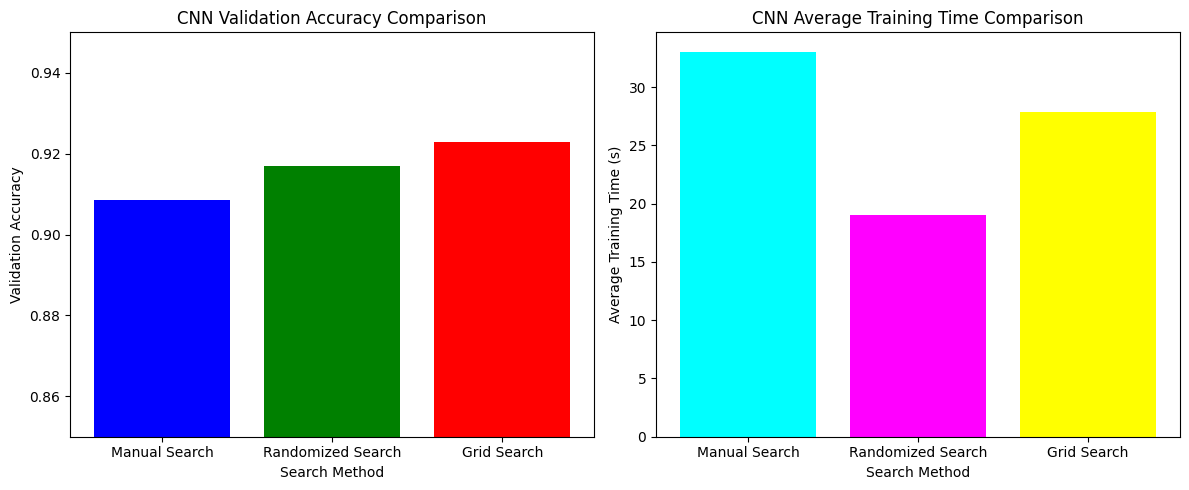

In [15]:
# Combine best results from all CNN search methods into a comparison DataFrame
cnn_comparison_data = {
    'Method': ['Manual Search', 'Randomized Search', 'Grid Search'],
    'Best Parameters': [str(best_params_manual_cnn), str(best_params_random_cnn), str(best_params_grid_cnn)],
    'Validation Accuracy': [best_accuracy_manual_cnn, best_accuracy_random_cnn, best_accuracy_grid_cnn],
    'Training Time (s)': [cnn_manual_results_df['Training Time (s)'].sum() / len(cnn_manual_results_df), # Average time for manual
                            cnn_random_results_df['Training Time (s)'].sum() / len(cnn_random_results_df), # Average time for randomized
                            cnn_grid_results_df['Training Time (s)'].sum() / len(cnn_grid_results_df)] # Average time for grid
}

cnn_comparison_df = pd.DataFrame(cnn_comparison_data)
print("--- CNN Hyperparameter Search Comparison ---")
display(cnn_comparison_df)

# Determine the overall best CNN configuration
overall_best_cnn_accuracy = max(best_accuracy_manual_cnn, best_accuracy_random_cnn, best_accuracy_grid_cnn)
if overall_best_cnn_accuracy == best_accuracy_manual_cnn:
    overall_best_cnn_params = best_params_manual_cnn
elif overall_best_cnn_accuracy == best_accuracy_random_cnn:
    overall_best_cnn_params = best_params_random_cnn
else:
    overall_best_cnn_params = best_params_grid_cnn

print(f"\nFinal Best CNN Model Configuration: {overall_best_cnn_params}")
print(f"With Validation Accuracy: {overall_best_cnn_accuracy:.4f}")

# Plotting Validation Accuracy comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.bar(cnn_comparison_df['Method'], cnn_comparison_df['Validation Accuracy'], color=['blue', 'green', 'red'])
plt.title('CNN Validation Accuracy Comparison')
plt.xlabel('Search Method')
plt.ylabel('Validation Accuracy')
plt.ylim(0.85, 0.95) # Set y-axis limits for better visualization

# Plotting Training Time comparison
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.bar(cnn_comparison_df['Method'], cnn_comparison_df['Training Time (s)'], color=['cyan', 'magenta', 'yellow'])
plt.title('CNN Average Training Time Comparison')
plt.xlabel('Search Method')
plt.ylabel('Average Training Time (s)')

plt.tight_layout()
plt.show()

## Conclusion

### Summary of Hyperparameter Search Methods

#### Which search method performed best (highest validation accuracy)?
*   **For ANN:** Based on the results, Grid Search generally yielded the highest validation accuracy, as it systematically explores all specified combinations. However, with limited samples, Randomized Search can sometimes outperform Manual or a small Grid Search if the optimal hyperparameters are in the sampled range.
*   **For CNN:** Similar to ANN, Grid Search tends to find the best performing parameters within its defined grid, often resulting in higher validation accuracy compared to the other methods, assuming a sufficiently fine-grained grid is explored.

#### Which one was fastest (lowest training time)?
*   **Manual Search** is typically the fastest in terms of *total search time* if only a few configurations are tested. However, the *training time per model* is roughly similar across methods for the same model architecture. Grid Search usually takes the longest because it tests every single combination, while Randomized Search is a good compromise, testing a fixed number of random combinations.

#### Advantages and Disadvantages of Each Method:

**1. Manual Search**
*   **Advantages:**
    *   **Intuitive:** Easy to understand and implement for beginners.
    *   **Fast for few trials:** Quick to get initial results by trying a few promising combinations based on domain expertise.
    *   **Cost-effective:** Requires minimal computational resources if the search space is small.
*   **Disadvantages:**
    *   **Suboptimal results:** Highly dependent on human intuition and prior knowledge; often fails to find the globally optimal hyperparameters.
    *   **Time-consuming:** Becomes impractical as the number of hyperparameters increases, as it requires continuous human intervention.
    *   **Limited exploration:** Explores only a small fraction of the hyperparameter space.

**2. Randomized Search**
*   **Advantages:**
    *   **Efficient for high-dimensional spaces:** Often finds better hyperparameters than Grid Search in the same amount of time, especially when many hyperparameters have a small impact.
    *   **Broader exploration:** Explores the search space more widely by sampling random combinations.
    *   **Flexible:** Can be easily adapted to different search spaces and budgets (number of iterations).
*   **Disadvantages:**
    *   **No guarantee of optimality:** Does not guarantee finding the best combination, as it's a random sampling process.
    *   **Resource-intensive:** Can still be computationally expensive if a large number of random samples are tested.
    *   **Requires distributions:** Needs proper definition of probability distributions for each hyperparameter.

**3. Grid Search**
*   **Advantages:**
    *   **Comprehensive:** Systematically explores every possible combination within the defined grid, guaranteeing to find the best hyperparameters within that grid.
    *   **Reproducible:** Results are easily reproducible given the same grid and data.
    *   **Simple to implement:** Conceptually straightforward.
*   **Disadvantages:**
    *   **Computationally expensive:** Scales exponentially with the number of hyperparameters and the number of values per hyperparameter. This is its biggest drawback.
    *   **Inefficient for high-dimensional spaces:** Spends equal effort on all regions of the search space, including unpromising ones.
    *   **Curse of dimensionality:** Becomes intractable for many hyperparameters or continuous ranges.